# Notebook 06 — 1D Convolutional Neural Network Training

**CMSC 190 Special Problem**
*Classification of High-Protein and Low-Protein Corn (Zea Mays) Using NIR Spectral Data and Machine Learning Techniques*

---

This notebook builds, trains, and evaluates a **1D Convolutional Neural Network (1D-CNN)** on the preprocessed and augmented NIR spectral data produced by the previous notebooks.

| Notebook | What it did |
|---|---|
| 01 | Loaded and explored the raw NIR data |
| 02 | Assigned High / Low protein binary labels |
| 03 | Applied Savitzky-Golay smoothing |
| 04 | Split the data and augmented the training set |
| 05 | Trained and evaluated PLS-DA and SVM |
| **06 (this notebook)** | **Trains and evaluates the 1D-CNN** |

**Output:** `saved_models/1d_cnn_best.h5`

## Section 1 — Imports and Setup

This cell imports all the libraries we need and sets random seeds to make sure our results are the same every time the notebook is run.

We also import the helper functions from `src/cnn_trainer.py`, which contains all the CNN-specific logic for this notebook.

> **Key advantage of 1D-CNN over PLS-DA and SVM:**
> The 1D-CNN **automatically learns which spectral features matter** directly from the raw wavelength data during backpropagation — no manual feature engineering (like PLS components or kernel tricks) is needed. The convolutional filters act as learnable pattern detectors that slide across the spectrum, capturing local absorption relationships that human-designed features might miss.

In [19]:
import importlib
import os
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Allow Python to find the src/ package one directory above notebooks/
sys.path.append('..')

# Force Python to re-read src/ files from disk instead of using any
# cached (stale) module version from previous kernel runs.
for _mod in list(sys.modules.keys()):
    if _mod.startswith('src.'):
        del sys.modules[_mod]
importlib.invalidate_caches()

import tensorflow as tf

# --- Reproducibility seeds (set BEFORE any other TF/Keras calls) ---
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# --- Custom helper functions ---
from src.cnn_trainer import (
    build_1d_cnn,
    evaluate_cnn,
    plot_cnn_confusion_matrix,
    plot_training_history,
    reshape_for_cnn,
    scale_for_cnn,
    train_cnn,
)
from src.trainer import save_model

# --- Plot style ---
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print("All imports successful.")
print(f"TensorFlow version : {tf.__version__}")

All imports successful.
TensorFlow version : 2.21.0


## Section 2 — Load Data

Here we load the four NumPy arrays that were produced by the previous notebooks.

- **`X_train_augmented.npy`** — augmented training spectra (shape: n_samples × 700 wavelengths)
- **`y_train_augmented.npy`** — labels for the augmented training set
- **`X_test.npy`** — original held-out test spectra (never used for training)
- **`y_test.npy`** — labels for the held-out test set

> **Important:** `X_test` and `y_test` are **only used in Section 7** for final evaluation.
> They are loaded here purely to confirm the shapes are correct.
> We will NOT modify, augment, or preprocess them further.

In [20]:
# Load pre-processed and augmented data from the data/processed/ folder.
# Paths are relative to the notebooks/ directory.
X_train = np.load('../data/processed/X_train_augmented.npy')
y_train = np.load('../data/processed/y_train_augmented.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_test  = np.load('../data/processed/y_test.npy')

print("=== Array Shapes ===")
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")

print("\n=== Class Distribution (y_train) ===")
classes, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(classes, counts):
    label = 'High Protein' if cls == 1 else 'Low Protein'
    print(f"  Class {int(cls)} ({label}): {cnt} samples")

print("\n=== Class Distribution (y_test) ===")
classes_t, counts_t = np.unique(y_test, return_counts=True)
for cls, cnt in zip(classes_t, counts_t):
    label = 'High Protein' if cls == 1 else 'Low Protein'
    print(f"  Class {int(cls)} ({label}): {cnt} samples")

=== Array Shapes ===
X_train : (2000, 700)
y_train : (2000,)
X_test  : (16, 700)
y_test  : (16,)

=== Class Distribution (y_train) ===
  Class 0 (Low Protein): 1012 samples
  Class 1 (High Protein): 988 samples

=== Class Distribution (y_test) ===
  Class 0 (Low Protein): 8 samples
  Class 1 (High Protein): 8 samples


## Scaling the Input Data

Before feeding the spectra into the CNN, we apply **StandardScaler** normalization.

This transforms each of the 700 wavelength channels so that it has **mean = 0** and **standard deviation = 1** across all training samples. CNNs are sensitive to input scale — without normalization, the gradients during backpropagation become very uneven across wavelengths, which caused the model to get stuck at ~50% accuracy (random guessing).

**Why fit only on `X_train`?**
The scaler learns the mean and std from the training set only. Applying those same parameters to `X_test` ensures we do not leak any information from the test set into the model — a form of *data-leakage prevention*.

The fitted scaler is also saved to `saved_models/cnn_scaler.pkl` for use during inference in Notebook 07.

In [21]:
X_train_scaled, X_test_scaled, cnn_scaler = scale_for_cnn(X_train, X_test)

CNN scaler saved to ../saved_models/cnn_scaler.pkl
X_train_scaled shape: (2000, 700)
X_test_scaled shape : (16, 700)


## Section 3 — Reshape Data for CNN Input

Before feeding the spectra into the 1D-CNN, we need to add an extra dimension.

**Why?**
Keras `Conv1D` expects its input to have shape `(samples, timesteps, features)` — a 3D tensor.

- **`samples`** — the number of spectra (rows)
- **`timesteps`** — the number of wavelength points (700 in our case)
- **`features`** — the number of values at each timestep (1 here, because each wavelength has exactly one absorbance reading)

Think of the 700-point NIR spectrum as a time series where each "moment in time" is a single wavelength, and the "signal value" at that moment is the absorbance. The `Conv1D` filters then slide along this sequence, learning to recognise absorption patterns across neighboring wavelengths.

`reshape_for_cnn()` handles this transformation automatically.

In [22]:
# Reshape the SCALED splits from (n_samples, 700) → (n_samples, 700, 1)
# so they are compatible with the Conv1D input layer.
X_train_cnn = reshape_for_cnn(X_train_scaled)
X_test_cnn  = reshape_for_cnn(X_test_scaled)

print("Shapes after reshaping:")
print(f"  X_train_cnn : {X_train_cnn.shape}  (expected: (n_samples, 700, 1))")
print(f"  X_test_cnn  : {X_test_cnn.shape}  (expected: (n_samples, 700, 1))")

Shapes after reshaping:
  X_train_cnn : (2000, 700, 1)  (expected: (n_samples, 700, 1))
  X_test_cnn  : (16, 700, 1)  (expected: (n_samples, 700, 1))


## Section 4 — Build the 1D-CNN Model

This cell creates the neural network architecture. The `build_1d_cnn()` function returns a compiled Keras model and prints a layer-by-layer summary.

Here is what each layer does in plain English:

| Layer | Purpose |
|---|---|
| **Conv1D (64 filters, kernel 7)** | Scans the spectrum with 64 small windows of width 7 wavelengths each. Each filter learns to recognise a different local absorption pattern. |
| **MaxPooling1D (pool 2)** | Halves the sequence length by keeping only the strongest activation in each pair of neighboring positions. Reduces computation and focuses on the most prominent features. |
| **Conv1D (128 filters, kernel 5)** | A second, deeper scanning layer that combines the patterns found by the first layer into 128 higher-level spectral features. |
| **MaxPooling1D (pool 2)** | Halves the sequence length again, further compressing the representation. |
| **Flatten** | Converts the 2D feature map (sequence × filters) into a single long 1D vector so it can be fed into Dense layers. |
| **Dense (64 units, relu)** | A fully-connected layer that learns non-linear combinations of all the extracted spectral features. |
| **Dropout (rate 0.3)** | Randomly turns off 30% of the neurons during every training step. This forces the network to learn redundant representations and prevents overfitting. |
| **Dense (32 units, relu)** | A second fully-connected layer that refines the feature combinations. |
| **Dense (1 unit, sigmoid)** | The output neuron. Sigmoid squashes the output to a value between 0 and 1. Values **≥ 0.5** are classified as **High Protein (1)**; values **< 0.5** are **Low Protein (0)**. |

In [23]:
# Build and compile the 1D-CNN.
# The function prints the full model summary automatically.
model = build_1d_cnn(input_length=700)

Model: "1d_cnn_protein_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 700, 32)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 700, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 350, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 350, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 350, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 175, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 11200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │       358,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373,633 (1.43 MB)

 Trainable params: 373,441 (1.42 MB)

 Non-trainable params: 192 (768.00 B)

## Section 5 — Train the Model

This cell runs the actual training loop. Two safety mechanisms are active throughout:

**EarlyStopping**
- Monitors `val_loss` (the loss on the 10% validation slice) after every epoch.
- If `val_loss` does not improve for **10 consecutive epochs**, training stops automatically.
- The model is then rolled back to the weights that achieved the best `val_loss` (`restore_best_weights=True`).
- This prevents the model from continuing to memorise the training data long after it has stopped generalising.

**ModelCheckpoint**
- After every epoch, if `val_loss` is the lowest seen so far, the model is saved to `saved_models/1d_cnn_best.h5`.
- Only the single best checkpoint is kept (`save_best_only=True`).
- This guarantees that even if training is interrupted, the best weights are preserved on disk.

**Data split during training:**
The 90 / 10 split of `X_train_cnn` happens internally inside Keras — **the 10% held-out validation samples are a random subset of the training data, not the test set.**

In [24]:
# Train the model.
# - epochs=100     : maximum number of passes over the training data
# - batch_size=64  : number of samples processed before each weight update
# - validation_split=0.1 : 10% of X_train_cnn is used as a validation set
# - random_state=42: ensures reproducibility of the TF random operations
history = train_cnn(
    model,
    X_train_cnn,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    random_state=42,
)

Epoch 1/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5895 - loss: 0.7817
Epoch 1: val_loss improved from None to 0.69314, saving model to ../saved_models/1d_cnn_best.h5



Epoch 1: finished saving model to ../saved_models/1d_cnn_best.h5
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5906 - loss: 0.7415 - val_accuracy: 0.4650 - val_loss: 0.6931
Epoch 2/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6304 - loss: 0.6244
Epoch 2: val_loss did not improve from 0.69314
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6539 - loss: 0.6081 - val_accuracy: 0.4850 - val_loss: 0.6962
Epoch 3/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6819 - loss: 0.5883
Epoch 3: val_loss improved from 0.69314 to 0.69097, saving model to ../saved_models/1d_cnn_best.h5



Epoch 3: finished saving model to ../saved_models/1d_cnn_best.h5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6972 - loss: 0.5674 - val_accuracy: 0.5000 - val_loss: 0.6910
Epoch 4/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7278 - loss: 0.5345
Epoch 4: val_loss did not improve from 0.69097
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7383 - loss: 0.5198 - val_accuracy: 0.5150 - val_loss: 0.6952
Epoch 5/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7397 - loss: 0.5173
Epoch 5: val_loss did not improve from 0.69097
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7633 - loss: 0.4834 - val_accuracy: 0.5050 - val_loss: 0.6951
Epoch 6/100
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7505 - loss: 0.4744
Epoch 6: val_loss did not improve from 0.69097
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7622 - loss: 0.4567 - val_accuracy: 0.4850 - val_loss: 0.6961
Epoch 7/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7866 


Epoch 9: finished saving model to ../saved_models/1d_cnn_best.h5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8361 - loss: 0.3707 - val_accuracy: 0.5200 - val_loss: 0.6712
Epoch 10/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8304 - loss: 0.3614
Epoch 10: val_loss improved from 0.67125 to 0.63110, saving model to ../saved_models/1d_cnn_best.h5



Epoch 10: finished saving model to ../saved_models/1d_cnn_best.h5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8400 - loss: 0.3457 - val_accuracy: 0.6300 - val_loss: 0.6311
Epoch 11/100
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8413 - loss: 0.3441
Epoch 11: val_loss improved from 0.63110 to 0.62418, saving model to ../saved_models/1d_cnn_best.h5


...


Epoch 49: finished saving model to ../saved_models/1d_cnn_best.h5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9383 - loss: 0.1497 - val_accuracy: 0.9450 - val_loss: 0.1618
Epoch 50/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9371 - loss: 0.1480
Epoch 50: val_loss did not improve from 0.16184
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9378 - loss: 0.1556 - val_accuracy: 0.9350 - val_loss: 0.1740
Epoch 51/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9362 - loss: 0.1576
Epoch 51: val_loss did not improve from 0.16184
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9411 - loss: 0.1541 - val_accuracy: 0.9400 - val_loss: 0.1679
Epoch 52/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9467 - loss: 0.1539
Epoch 52: val_loss did not improve from 0.16184
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9489 - loss: 0.1475 - val_accuracy: 0.9400 - val_loss: 0.1749
Epoch 53/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy:


Epoch 55: finished saving model to ../saved_models/1d_cnn_best.h5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9411 - loss: 0.1503 - val_accuracy: 0.9350 - val_loss: 0.1605
Epoch 56/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9468 - loss: 0.1391
Epoch 56: val_loss did not improve from 0.16048
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9439 - loss: 0.1396 - val_accuracy: 0.9450 - val_loss: 0.1625
Epoch 57/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9610 - loss: 0.1241
Epoch 57: val_loss did not improve from 0.16048
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9522 - loss: 0.1297 - val_accuracy: 0.9350 - val_loss: 0.1678
Epoch 58/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9422 - loss: 0.1342
Epoch 58: val_loss did not improve from 0.16048
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9433 - loss: 0.1358 - val_accuracy: 0.9400 - val_loss: 0.1706
Epoch 59/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy:


Epoch 59: finished saving model to ../saved_models/1d_cnn_best.h5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9511 - loss: 0.1273 - val_accuracy: 0.9350 - val_loss: 0.1596
Epoch 60/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9549 - loss: 0.1234
Epoch 60: val_loss did not improve from 0.15964
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9494 - loss: 0.1284 - val_accuracy: 0.9350 - val_loss: 0.1695
Epoch 61/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9526 - loss: 0.1277
Epoch 61: val_loss did not improve from 0.15964
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9511 - loss: 0.1296 - val_accuracy: 0.9400 - val_loss: 0.1673
Epoch 62/100
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9484 - loss: 0.1350
Epoch 62: val_loss did not improve from 0.15964
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9489 - loss: 0.1359 - val_accuracy: 0.9450 - val_loss: 0.1686
Epoch 63/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy:


Epoch 63: finished saving model to ../saved_models/1d_cnn_best.h5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9517 - loss: 0.1300 - val_accuracy: 0.9500 - val_loss: 0.1555
Epoch 64/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9531 - loss: 0.1239
Epoch 64: val_loss improved from 0.15554 to 0.14697, saving model to ../saved_models/1d_cnn_best.h5



Epoch 64: finished saving model to ../saved_models/1d_cnn_best.h5
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9528 - loss: 0.1271 - val_accuracy: 0.9400 - val_loss: 0.1470
Epoch 65/100
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9564 - loss: 0.1150
Epoch 65: val_loss did not improve from 0.14697
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9572 - loss: 0.1142 - val_accuracy: 0.9350 - val_loss: 0.1677
Epoch 66/100
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9578 - loss: 0.1148
Epoch 66: val_loss did not improve from 0.14697
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9506 - loss: 0.1203 - val_accuracy: 0.9350 - val_loss: 0.1518
Epoch 67/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9607 - loss: 0.1070
Epoch 67: val_loss did not improve from 0.14697
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9583 - loss: 0.1140 - val_accuracy: 0.9400 - val_loss: 0.1605
Epoch 68/100
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy:

## Section 6 — Plot Training History

The two charts below show how the model's performance changed over each epoch of training.

**What to look for:**

- **Healthy training** — both the training loss and validation loss decrease steadily together, and both accuracy curves rise together. This means the model is learning genuine spectral patterns, not just memorising the training data.

- **Overfitting** — if the training loss keeps going down but the validation loss flattens or rises, the model has started memorising the training examples instead of generalising. The gap between the two curves is the "overfitting gap".

- **EarlyStopping at work** — if training stopped before epoch 50, the vertical position where the curves end shows how many epochs were actually needed. The saved model uses the weights from the epoch with the lowest validation loss (the best point on the `val_loss` curve).

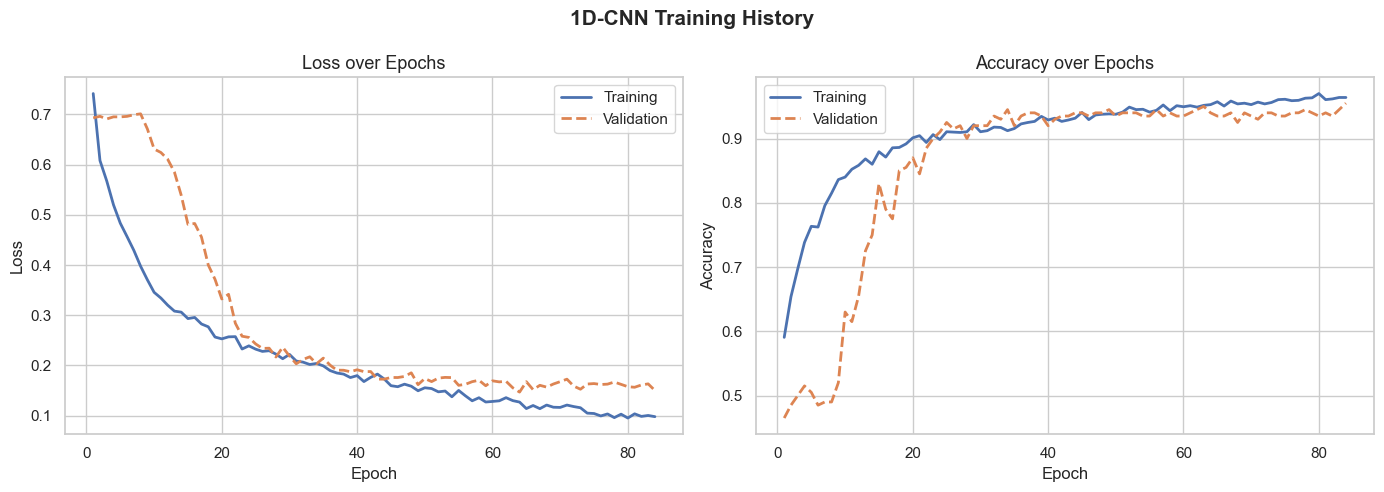

In [25]:
# Plot the loss and accuracy curves recorded during training.
plot_training_history(history)

## Section 7 — Evaluate on Test Set

> **This is the first and only time `X_test` and `y_test` are used.**

We now run the trained model on the 80 held-out test samples that were set aside in Notebook 04 and have not been seen during training, validation, or hyperparameter tuning.

The metrics reported here (Accuracy, Precision, Recall, F1-Score) are the **official final metrics for the 1D-CNN**. They will be carried forward to Notebook 07 for the head-to-head comparison against PLS-DA and SVM.

The confusion matrix shows:
- **True Positives** (top-left): High-Protein samples correctly identified as High Protein
- **True Negatives** (bottom-right): Low-Protein samples correctly identified as Low Protein
- **False Positives** (top-right): Low-Protein samples incorrectly predicted as High Protein
- **False Negatives** (bottom-left): High-Protein samples incorrectly predicted as Low Protein

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

  Evaluation Results — 1D-CNN
  Accuracy  : 0.8750
  Precision : 0.8000
  Recall    : 1.0000
  F1-Score  : 0.8889



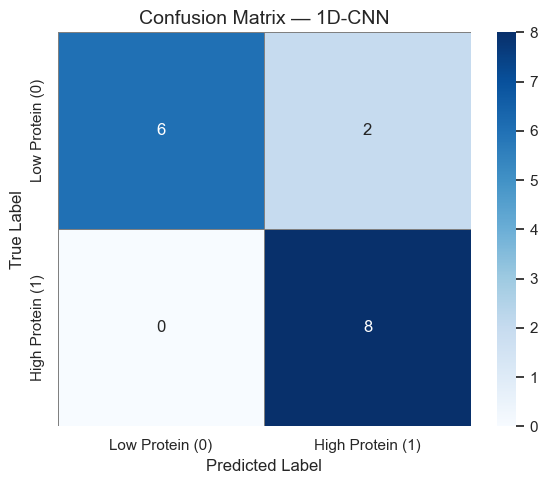

In [26]:
# Evaluate the trained model on the held-out test set.
# Predictions use threshold=0.5: sigmoid >= 0.5 → High Protein (1)
results_cnn = evaluate_cnn(model, X_test_cnn, y_test)

# Plot the confusion matrix for the test-set predictions.
plot_cnn_confusion_matrix(y_test, results_cnn['y_pred'])

## Section 8 — Save the Model

The best model weights were already saved **automatically** to `saved_models/1d_cnn_best.h5` by the `ModelCheckpoint` callback during training. No manual saving is needed.

The cell below simply confirms that the file is present on disk.

> **Note for Notebook 07:** When building the final comparison, Notebook 07 will load:
> - `saved_models/pls_da_best.pkl` — best PLS-DA model (saved in Notebook 05)
> - `saved_models/svm_best.pkl`    — best SVM model (saved in Notebook 05)
> - `saved_models/1d_cnn_best.h5`  — best 1D-CNN model (saved in this notebook)
>
> All three models will be evaluated on the same `X_test` and `y_test` arrays for a fair, controlled comparison.

In [27]:
import os

path = '../saved_models/1d_cnn_best.h5'

if os.path.exists(path):
    size_kb = os.path.getsize(path) / 1024
    print(f"Model saved successfully: {path}  ({size_kb:.1f} KB)")
else:
    print("WARNING: Model file not found. Check training output.")

Model saved successfully: ../saved_models/1d_cnn_best.h5  (4436.3 KB)


## Section 9 — Summary

This notebook trained and evaluated a 1D Convolutional Neural Network on NIR spectral data for binary protein classification of corn samples.

---

### Model Architecture

```
Input  →  Conv1D(64, k=7, relu, same)  →  MaxPool(2)
       →  Conv1D(128, k=5, relu, same) →  MaxPool(2)
       →  Flatten
       →  Dense(64, relu)  →  Dropout(0.3)
       →  Dense(32, relu)
       →  Dense(1, sigmoid)
```

### Input Shape
`(n_samples, 700, 1)` — 700 NIR wavelength points per sample, treated as a 1D sequence

### Training Configuration

| Setting | Value |
|---|---|
| Optimizer | Adam (lr = 0.001) |
| Loss function | Binary cross-entropy |
| Maximum epochs | 50 |
| Batch size | 32 |
| Validation split | 10% of training data |

### Regularization Strategy

| Technique | Configuration |
|---|---|
| EarlyStopping | Monitors `val_loss`, patience = 10, restores best weights |
| Dropout | Rate = 0.3 (applied after first Dense layer) |

### Output Artifact
`saved_models/1d_cnn_best.h5` — Keras model file holding the best weights found during training

### Evaluation Metrics (on held-out test set)
Accuracy, Precision, Recall, and F1-Score were computed on `X_test` / `y_test` — data the model has never seen before.

---

> **Next step — Notebook 07:** All three trained models (PLS-DA, SVM, and 1D-CNN) will be loaded from `saved_models/` and evaluated side-by-side on the same test set to determine which approach best classifies High-Protein and Low-Protein corn from NIR spectra.